# Предсказание   дохода



# Задача:

Целью данной задачи является построение модели **классификации пользователей**: на вход модель будет принимать данные о человеке, а на выходе она должна предсказывать бинарный уровень дохода человека (больше или меньше 50_000$ за год).

Выборка содержит 32561 наблюдение и 13 переменных, одна из которых — целевая (income). Все объекты были предварительно распределены на обучающую и тестовую части размерами 24420 и 8141 соответственно.

## Загрузка библиотек

In [56]:
from comet_ml import Experiment

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve
# команда указывает, что графики нужно строить прямо в ноутбуке: 
%matplotlib inline

In [58]:
# !pip install comet_ml

# Инициализация эксперимента

Примечание: Для успешного запуска на платформе CometML необходимо:
1. Зарегистрироваться на платформе;
2. Создать на платформе новый экперимент (например predict-income);
3. Передать в ноутбук скопированный API Key (после всех экспериментов API Key удаляется из ноубука - конф. информация!);
4. Название workspace (берется на платформе);

In [113]:
# @title CometML set up
project_name = 'predict-income'
workspace = 'alexandermeshchaninov'
api_key = ''

In [60]:
experiment = Experiment(
    project_name=project_name, 
    workspace=workspace, 
    api_key = api_key, 
    log_code=True)

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : beautiful_pavilion_4534
COMET INFO:     url                   : https://www.comet.com/alexandermeshchaninov/predict-income/71d49678ac2549c28844f5f1d268d0a8
COMET INFO:   Metrics:
COMET INFO:     Accuracy LabelEncoded data  : 0.8048151332760103
COMET INFO:     Accuracy OneHotEncoded data : 0.8503869303525365
COMET INFO:     Roc ouc LabelEncoded data   : 0.784887114804627
COMET INFO:     Roc ouc OneHot data         : 0.8934757195739103
COMET INFO:   Parameters:
COMET INFO:     C                     : 1.0
COMET INFO:     categories            : auto
COMET INFO:     class_weight          : None
COMET INFO:     drop                  : None
COMET INFO:    

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/alexandermeshchaninov/predict-income/5aa65e1836184ec0a4dc358b8ddc23f7

COMET INFO: Couldn't find a Git repository in '/Users/alexander/Desktop/SKILLFACTORY/Занятия по DATASCIENCE/Lesson-36' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


## Загрузка данных

In [61]:
# %%capture
# !wget https://www.dropbox.com/s/1hfrcm09qtvoeoz/train.csv
# !wget https://www.dropbox.com/s/jj7c8r0x57zda0a/test.csv

In [62]:
train_data = pd.read_csv('Data/adult_train_df.csv')
test_data = pd.read_csv('Data/adult_test_df.csv')

In [63]:
train_data.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,49,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,0.0,0.0,40,United-States,0
1,27,NaN,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,45,United-States,0
2,44,NaN,11th,Married-civ-spouse,Other-service,Husband,Black,Male,0.0,0.0,60,United-States,0
3,59,Private,Bachelors,Separated,Adm-clerical,Unmarried,White,Male,0.0,0.0,60,United-States,0
4,54,Private,Bachelors,Divorced,Sales,Not-in-family,White,Female,0.0,1408.0,38,United-States,0


Проверим размерности наших файлов:

In [64]:
train_data.shape, test_data.shape

((24420, 13), (8141, 13))

**Работаем с целевой переменной**

In [65]:
target_name = 'income'

In [66]:
y_train = train_data[target_name]
y_test = test_data[target_name]

X_train = train_data.drop(columns=[target_name])
X_test = test_data.drop(columns=[target_name])

**Оценка сбалансированности выборки**

In [67]:
y_train.value_counts(normalize=True)

income
0    0.757821
1    0.242179
Name: proportion, dtype: float64

# Вывод:

Как мы видим, у нас задача **несбалансированной бинарной классификации**. 

## Общая статистика по числовым данным



In [68]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,24420.0,38.598116,13.638458,17.0,28.0,37.0,48.0,90.0
capital-gain,23705.0,1051.724067,7199.945441,0.0,0.0,0.0,0.0,99999.0
capital-loss,23936.0,88.409592,404.466154,0.0,0.0,0.0,0.0,4356.0
hours-per-week,24420.0,40.386568,12.299621,1.0,40.0,40.0,45.0,99.0


{'web': 'https://www.comet.com/api/image/download?imageId=65c22f9ffbcc4416afbbebf780f264f3&experimentKey=5aa65e1836184ec0a4dc358b8ddc23f7',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=65c22f9ffbcc4416afbbebf780f264f3&experimentKey=5aa65e1836184ec0a4dc358b8ddc23f7',
 'imageId': '65c22f9ffbcc4416afbbebf780f264f3'}

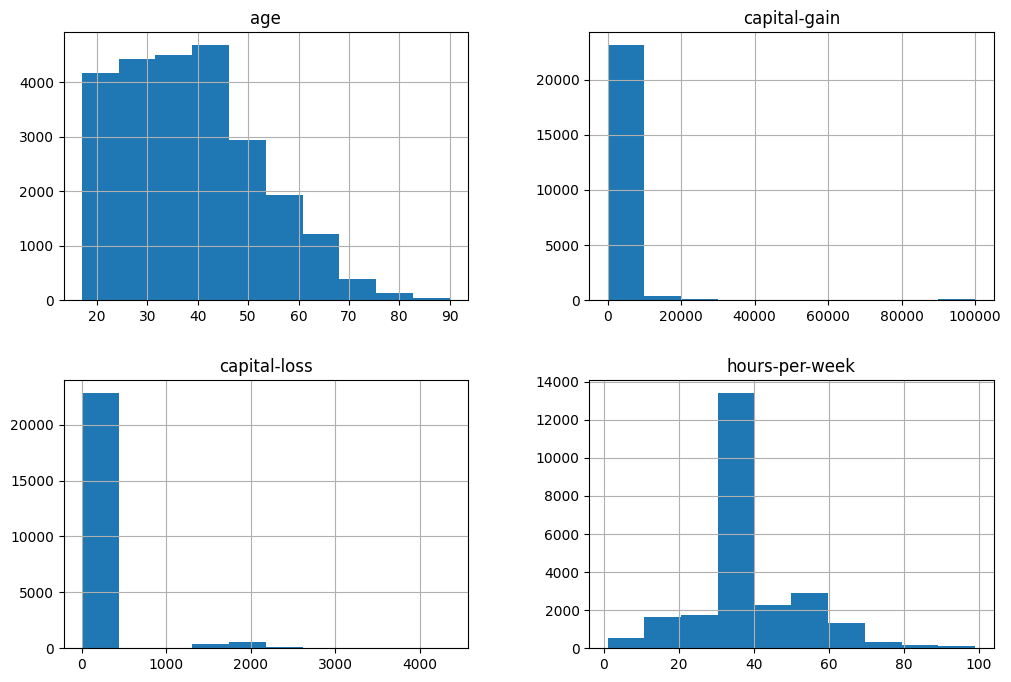

In [69]:
X_train.hist(figsize=(12,8))
experiment.log_figure('X_train_numeric_distr', plt)

# Вывод:

* Числовых переменных в исходных данных только 4;
* Возраст пользователя варьируется в диапазоне от 17 до 90 лет и в среднем составляет 39 лет;
* Видим пропуски в признаках capital-gain и capital-loss (значение count меньше размера данных). По гистограмме можно заметить, что большое количество значений в этих признаках - это просто нули;

# Предобработка данных

### Проверка на наличие пропусков и типов переменных

In [70]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             24420 non-null  int64  
 1   workclass       23223 non-null  object 
 2   education       23443 non-null  object 
 3   marital-status  24420 non-null  object 
 4   occupation      24420 non-null  object 
 5   relationship    24420 non-null  object 
 6   race            24420 non-null  object 
 7   sex             24420 non-null  object 
 8   capital-gain    23705 non-null  float64
 9   capital-loss    23936 non-null  float64
 10  hours-per-week  24420 non-null  int64  
 11  native-country  24420 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 2.2+ MB


In [71]:
X_train.isnull().sum()

age                  0
workclass         1197
education          977
marital-status       0
occupation           0
relationship         0
race                 0
sex                  0
capital-gain       715
capital-loss       484
hours-per-week       0
native-country       0
dtype: int64

# Вывод:

Типы в данных составляют:

* 8 признаков типа **object** - обычно это строковые значения;
* 3 признака типа **int64** - целочисленные значения (одна из них целевая переменная);
* 2 признака типа **float64** - числа с плавающей запятой.

Кроме этого, мы видим, что признаки *workclass, education, capital-gain и capital-loss* имеют пропуски в данных.

# Обработка пропусков в данных

Далеко не все алгоритмы умеют работать с пропусками в данных. Кроме этого, удачно заполнив пропуски, мы сможем лучше восстановить распределение данных, а значит лучше построить моделей. 

Самые популярные методы для обработки пропусков:
- Удаление значений с пропусками (не желательно при большом количестве пропусков, потому что теряются данные);
- Заполнение средним/медианным значением;
- Заполненние самым частым значением;
- Заполнение случайным значением.

**Важно:** тестовую выборку мы всегда обрабатываем также, как и обучающую выборку.

In [72]:
X_train['capital-loss'] = X_train['capital-loss'].fillna(0)
X_train['capital-gain'] = X_train['capital-gain'].fillna(0)

Сделаем то же самое для тестовой выборки:

In [73]:
X_test['capital-loss'] = X_test['capital-loss'].fillna(0)
X_test['capital-gain'] = X_test['capital-gain'].fillna(0)

In [74]:
X_train['workclass'].value_counts(True).head(1)

workclass
Private    0.696766
Name: proportion, dtype: float64

In [75]:
X_train['education'].value_counts(True).head(1)

education
HS-grad    0.322484
Name: proportion, dtype: float64

Наиболее частое значение признака **workclass** - Private, признака **education** - HS-grad. 

Теперь явно заполним пропуски:

In [76]:
X_train['workclass'] = X_train['workclass'].fillna('Private')
X_train['education'] = X_train['education'].fillna('HS-grad')

Сделаем то же самое для тестовой выборки:

In [77]:
X_test['workclass'] = X_test['workclass'].fillna('Private')
X_test['education'] = X_test['education'].fillna('HS-grad')

# Кодировка категориальных переменных

В данных 8 столбцов являются категориальными признаками. При чём в нашей задаче эти признаки **текстовые**. Моделям лучше предоставлять числовые признаки, поэтому нам необходимо закодировать их, то есть преобразовать в числовые.

Для начала необходимо выделить категорильные признаки:

In [78]:
categorical_features = ['workclass', 'education', 'marital-status', 
                        'occupation', 'relationship', 'race', 'sex', 
                        'native-country']

non_categorical_features = ['age', 'capital-gain', 'capital-loss', 
                            'hours-per-week']

Посмотрим на столбцы категориальных переменных:

In [79]:
X_train[categorical_features].head()

,workclass,education,marital-status,occupation,relationship,race,sex,native-country
0,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States
1,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States
2,Private,11th,Married-civ-spouse,Other-service,Husband,Black,Male,United-States
3,Private,Bachelors,Separated,Adm-clerical,Unmarried,White,Male,United-States
4,Private,Bachelors,Divorced,Sales,Not-in-family,White,Female,United-States


Мы рассмотрим два популярных метода кодирования категориальных признаков:

* Label Encoding, которому соответствует класс `LabelEncoder()` из библиотеки **sklearn**
* One Hot Encoding, которому соответствует класс `OneHotEncoder()` из библиотеки **sklearn**

# Label Encoding

In [80]:
# Создаем кодер
label_encoder = LabelEncoder()

# Копируем в отдельные переменные выборки
X_train_le = X_train.copy()
X_test_le = X_test.copy()

# Перебираем в цикле все категориальные признаки и кодируем их с помощью LabelEncoder
for feature in categorical_features:
    X_train_le[feature] = label_encoder.fit_transform(X_train_le[feature])
    X_test_le[feature] = label_encoder.transform(X_test_le[feature])

# Выводим закодированные данные
X_train_le.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,49,4,11,2,3,0,4,1,0.0,0.0,40,39
1,27,4,11,2,7,0,4,1,0.0,0.0,45,39
2,44,4,1,2,8,0,2,1,0.0,0.0,60,39
3,59,4,9,5,1,4,4,1,0.0,0.0,60,39
4,54,4,9,0,12,1,4,0,0.0,1408.0,38,39


# One Hot Encoding

In [81]:
# Создаем кодер
onehot_encoder = OneHotEncoder()

# 'учим' и сразу применяем преобразование к выборке, результат переводим в массив
X_train_onehot = onehot_encoder.fit_transform(X_train[categorical_features]).toarray()
# применяем полученное преобразование к тестовой выборке, результат переводим в массив
X_test_onehot = onehot_encoder.transform(X_test[categorical_features]).toarray()

# запишем полученные названия новых колонок в отдельную переменную
columns = onehot_encoder.get_feature_names_out(categorical_features)

# Создаем DataFrame c указанием столбкцов
X_train_onehot = pd.DataFrame(X_train_onehot, columns=columns)
X_test_onehot = pd.DataFrame(X_test_onehot, columns=columns)

# соединяем новую табличку с исходной
X_train_oh= pd.concat([X_train, X_train_onehot], axis=1)
X_test_oh = pd.concat([X_test, X_test_onehot], axis=1)

# удаляем старые категориальные признаки
X_train_oh = X_train_oh.drop(columns=categorical_features)
X_test_oh = X_test_oh.drop(columns=categorical_features)

# Выводим закодированые данные
X_train_oh.head()

,age,capital-gain,capital-loss,hours-per-week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,49,0.0,0.0,40,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,27,0.0,0.0,45,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,44,0.0,0.0,60,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,59,0.0,0.0,60,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,54,0.0,1408.0,38,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Обучение модели

## Выбор метода обучения классификатора

Для обучения классификатора воспользуемся логистической регрессией.
 

Создаем прототип класса модели:

In [82]:
linear_model_oh = LogisticRegression() # Закодированных данных OneHotEncoded
linear_model_le = LogisticRegression() # Для закодированных данных LabelEncoded

## Обучение модели на разных типах закодированных данных

In [83]:
linear_model_oh.fit(X_train_oh, y_train)

/Users/alexander/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [84]:
linear_model_le.fit(X_train_le, y_train)

/Users/alexander/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Валидация модели на тестовой выборке

In [85]:
prediction_oh = linear_model_oh.predict(X_test_oh)
np.unique(prediction_oh)

array([0, 1])

In [86]:
unique, counts = np.unique(prediction_oh, return_counts=True)
class_counts = dict(zip(unique, counts))

# Сколько 1го класса присутсвует в предсказаниях?
display(f'Распределения классов в данных: {class_counts}')

'Распределения классов в данных: {0: 6568, 1: 1573}'

In [87]:
unique, counts = np.unique(y_test, return_counts=True)
class_counts = dict(zip(unique, counts))

# Сколько 1го класса присутсвует в y_test?
display(f'Распределения классов в данных: {class_counts}')

'Распределения классов в данных: {0: 6214, 1: 1927}'

In [88]:
prediction_le = linear_model_le.predict(X_test_le)
np.unique(prediction_le)

array([0, 1])

In [89]:
unique, counts = np.unique(prediction_le, return_counts=True)
class_counts = dict(zip(unique, counts))

# Сколько 1го класса присутсвует в предсказаниях?
display(f'Распределения классов в данных: {class_counts}')

'Распределения классов в данных: {0: 7339, 1: 802}'

In [90]:
unique, counts = np.unique(y_test, return_counts=True)
class_counts = dict(zip(unique, counts))

# Сколько 1го класса присутсвует в y_test?
display(f'Распределения классов в данных: {class_counts}')

'Распределения классов в данных: {0: 6214, 1: 1927}'

# Точность предсказания

Посчитаем точность (**accuracy**) работы моделей. Точность отражает, сколько в процентном соотношении от размера тестовой выборки модель угадала 1 и сколько угадала 0.

Функция для подсчета точности реализована в библиотеке **sklearn** и называется `accuracy_score()`.

In [91]:
acc_oh = accuracy_score(y_test, prediction_oh)
display(f'Accuracy score (OneHotEncoded): {acc_oh:.2f} %')

'Accuracy score (OneHotEncoded): 0.85 %'

In [92]:
acc_le = accuracy_score(y_test, prediction_le)
display(f'Accuracy score (LabelEncoded): {acc_le:.2f} %')

'Accuracy score (LabelEncoded): 0.80 %'

# Залогируем эксперименты

In [93]:
# Залогируем accuracy для OneHot
experiment.log_metric('Accuracy OneHotEncoded data', acc_oh)

In [94]:
# Залогируем accuracy для LE
experiment.log_metric('Accuracy LabelEncoded data', acc_le)

Сравним значения точности для наших моделей с точностью для константного классификатора, модели, которая всегда бы предсказывала больший класс, в нашем случае 0. Для этого можно в функцию `accuracy_score()` в качестве второго аргумента передать массив нулей такого же размера. Это делается с помощью функции `zeros_like()` из библиотеки **numpy**.

In [95]:
acc_major_class_oh = accuracy_score(y_test, np.zeros_like(y_test))
display(f'Accuracy Major Class: {acc_major_class_oh:.2f} %')

'Accuracy Major Class: 0.76 %'

# Вывод:

Делаем вывод на основе полученных метрик, что **логистическая регрессия** c OneHot справилась лучше с предсказаниями, чем LabelEncoded - accuracy: 85 % против 81 %.

# Таблица сопряженности модели классификации

Другой способ оценивать качество работы классификатора - использовать таблицу сопряженности. 

|                   |  Предсказано `0` |  Предсказано `1` |
|:-------------------|:------------------|:------------------|
|**Фактически** `0`  |       TN         |       FP         |
|**Фактически** `1`  |       FN         |       TP         | 


In [96]:
pd.DataFrame(confusion_matrix(y_test, prediction_oh))

,0,1
0,5782,432
1,786,1141


In [97]:
experiment.log_confusion_matrix(y_test, prediction_oh)

{'web': 'https://www.comet.com/api/asset/download?assetId=ca02a1e4e4ab426fbb0e3a5e1afc5567&experimentKey=5aa65e1836184ec0a4dc358b8ddc23f7',
 'api': 'https://www.comet.com/api/rest/v2/experiment/asset/get-asset?assetId=ca02a1e4e4ab426fbb0e3a5e1afc5567&experimentKey=5aa65e1836184ec0a4dc358b8ddc23f7',
 'assetId': 'ca02a1e4e4ab426fbb0e3a5e1afc5567'}

# Прогноз вероятности принадлежности к классу

In [98]:
pred_proba_oh = linear_model_oh.predict_proba(X_test_oh)

# Как выглядят предсказания?
display(pred_proba_oh)

array([[0.95581028, 0.04418972],
       [0.43249005, 0.56750995],
       [0.26230719, 0.73769281],
       ...,
       [0.99712616, 0.00287384],
       [0.37557293, 0.62442707],
       [0.67353301, 0.32646699]])

In [99]:
pred_proba = pred_proba_oh[:, 1]
display(f'Вероятность принадлежености к 1 классу: {pred_proba}')

'Вероятность принадлежености к 1 классу: [0.04418972 0.56750995 0.73769281 ... 0.00287384 0.62442707 0.32646699]'

Посмотрим на распределение предсказанной классификатором вероятности дохода > 50к, метки `1`.

{'web': 'https://www.comet.com/api/image/download?imageId=1068eb2458144c31b56f3e18543820dc&experimentKey=5aa65e1836184ec0a4dc358b8ddc23f7',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=1068eb2458144c31b56f3e18543820dc&experimentKey=5aa65e1836184ec0a4dc358b8ddc23f7',
 'imageId': '1068eb2458144c31b56f3e18543820dc'}

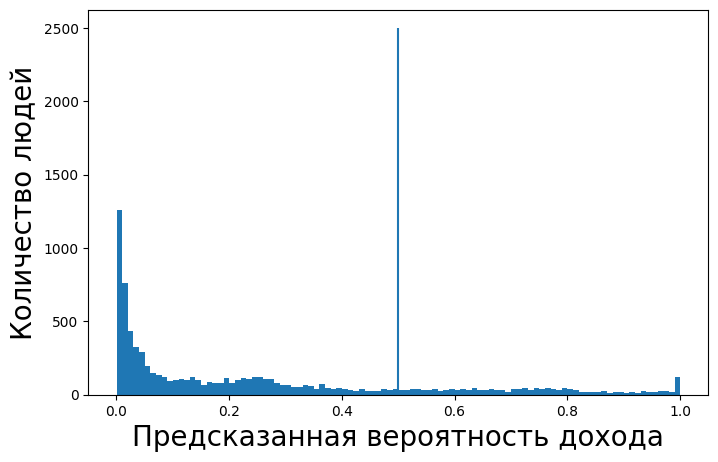

In [100]:
plt.figure(figsize=(8, 5))

plt.hist(pred_proba, bins=100)
plt.vlines(0.5, 0, 2500)

plt.xlabel('Предсказанная вероятность дохода', fontsize=20)
plt.ylabel('Количество людей', fontsize=20)

experiment.log_figure('predicted_income_probability', plt)

# ROC кривая классификатора

Если хотят сравнить метрики на разных наборах данных, обычно работают не с абсолютными значениями True Positive и False Positive, а с их долями:

* Доля ложноположительных срабатываний $\text{FPR} = \frac{FP}{FP + TN}$;
* Доля истинно положительных срабатываний $\text{TPR} = \frac{TP}{TP + FN}$.

Заметим, что $FP + TN$ дает общее число объектов класса $0$, а $TP + FN$ - общее число объектов класса $1$. 

Одной из самых популярных метрик для задачи классификации является ROC кривая. ROC расшифровывается как *Receiver Operating Characteristic*. Эта кривая наглядно показывает зависимость доли истинно позитивных срабатываний (**TPR**) от доли ложно позитивных срабатываний (**FPR**) при изменении порога классификации.

Функция `roc_curve()` из **scikit-learn** позволяет получить координаты точек ROC кривой, а также значения порога `threshold`, при котором достигается соответствующие значения метрик **FPR** и **TPR**.

На вход функции `roc_curve()` необходимо передать два аргумента:
* истинные значения меток
* вероятности, предсказанные моделью

# Для OneHot

In [101]:
false_positive_rates, true_positive_rates, threshold = roc_curve(y_test, pred_proba)

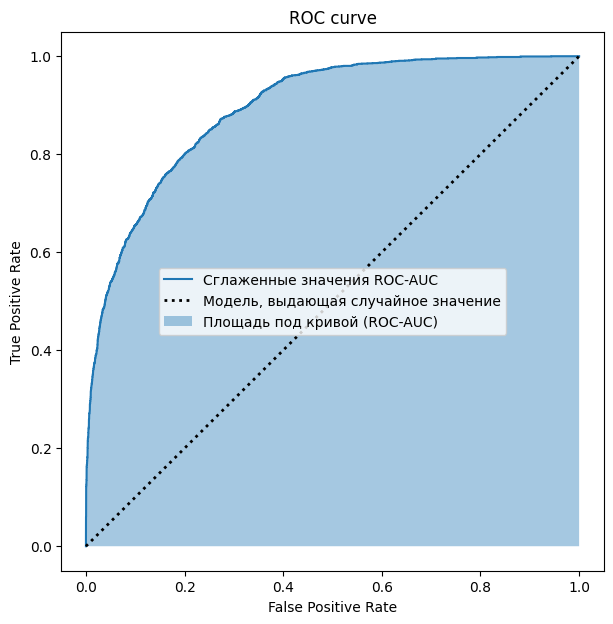

In [ ]:
# создаём график
plt.figure(figsize=(7, 7))

# рисуем кривую
plt.plot(false_positive_rates, true_positive_rates, 
         label='Сглаженные значения ROC-AUC')

# кривая, соответствующая случайному угадыванию
plt.plot([0, 1], [0, 1], color='k', lw=2, linestyle=':', 
         label='Модель, выдающая случайное значение')

plt.title('ROC curve OneHotEncoded')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.fill_between(false_positive_rates, true_positive_rates, step="pre", 
                 alpha=0.4, label='Площадь под кривой (ROC-AUC)')
plt.legend()
plt.show()

In [103]:
roc_auc_oh = roc_auc_score(y_test, pred_proba)
print(f"ROC-AUC на тестовой выборке OneHotEncoded: {roc_auc_oh:.3f}")

ROC-AUC на тестовой выборке OneHotEncoded: 0.893


In [111]:
experiment.log_metric('Roc ouc OneHot data', roc_auc_oh)

# Для LabelEncoded

In [105]:
pred_proba_le = linear_model_le.predict_proba(X_test_le)

In [106]:
pred_proba = pred_proba_le[:, 1]

In [107]:
false_positive_rates, true_positive_rates, threshold = roc_curve(y_test, pred_proba)

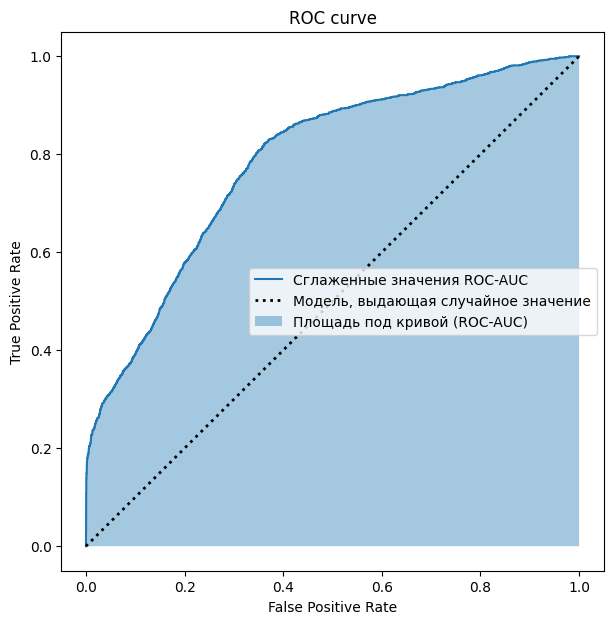

In [ ]:
# создаём график
plt.figure(figsize=(7, 7))

# рисуем кривую
plt.plot(false_positive_rates, true_positive_rates, 
         label='Сглаженные значения ROC-AUC')

# кривая, соответствующая случайному угадыванию
plt.plot([0, 1], [0, 1], color='k', lw=2, linestyle=':', 
         label='Модель, выдающая случайное значение')

plt.title('ROC curve LabelEncoded')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.fill_between(false_positive_rates, true_positive_rates, step="pre", 
                 alpha=0.4, label='Площадь под кривой (ROC-AUC)')
plt.legend()
plt.show()

In [109]:
roc_auc_le = roc_auc_score(y_test, pred_proba)
print(f"ROC-AUC на тестовой выборке LabelEncoded: {roc_auc_le:.3f}")

ROC-AUC на тестовой выборке LabelEncoded: 0.785


In [112]:
experiment.log_metric('Roc ouc LabelEncoded data', roc_auc_le)

# Вывод:

В качестве финального вывода можно с уверенностью сказать, что модель логистической регрессии с OneHot кодированием лучше различает классы чем с кодированием LabelEncoded. Это подтверждают метрики и графики Roc.

### Все результаты в CometML можно посмотреть по ссылке: 

- https://www.comet.com/alexandermeshchaninov/predict-income/reports/prediction-income-with-two-models/edit